In [ ]:
# Mount drive

from google.colab import drive

drive.mount('/content/drive')

!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu118


Mounted at /content/drive


In [ ]:
# Učitavanje i priprema Faster modela

import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
klase = 2

model = fasterrcnn_resnet50_fpn(
    weights="DEFAULT",
    box_detections_per_img=1000,
)

# Zamjena klasifikatora
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, klase)

model.to(device)

print("Model učitan")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 174MB/s]


Model učitan


In [ ]:
# Definiranje Dataset-a i loadera

import torch
from torch.utils.data import Dataset, DataLoader
import json
import os
from PIL import Image
import torchvision.transforms.functional as F

# Transform u tensor i normalizacija
class SafeTransform:
    def __init__(self, train=True):
        self.train = train
    def __call__(self, image, target):
        image = F.to_tensor(image)
        image = F.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        return image, target

# Dataset
class VEDAIDataset(Dataset):
    def __init__(self, images_dir, json_file, transforms):
        self.images_dir = images_dir
        self.transforms = transforms

        with open(json_file) as f:
            data = json.load(f)

        self.images_info = {img['id']: img for img in data['images']}
        self.annotations = data['annotations']

        self.img_to_annots = {}
        for ann in self.annotations:
            self.img_to_annots.setdefault(ann['image_id'], []).append(ann)

        self.ids = [
            img_id for img_id in self.images_info
            if img_id in self.img_to_annots
        ]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.images_info[img_id]
        img_path = os.path.join(self.images_dir, img_info['file_name'])

        image = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []

        for ann in self.img_to_annots[img_id]:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        image, target = self.transforms(image, target)

        return image, target, img_info['file_name']

# Putanje
train_images = "/content/drive/MyDrive/VEDAI_slike/treniranje/images"
train_json   = "/content/drive/MyDrive/VEDAI_slike/treniranje/annotations.json"

val_images = "/content/drive/MyDrive/VEDAI_slike/validacija/images"
val_json   = "/content/drive/MyDrive/VEDAI_slike/validacija/annotations.json"

test_images = "/content/drive/MyDrive/VEDAI_slike/testiranje/images"
test_json   = "/content/drive/MyDrive/VEDAI_slike/testiranje/annotations.json"

pred_folder = "/content/drive/MyDrive/VEDAI_slike/Rezultati/Faster/predictions"
metrics_folder = "/content/drive/MyDrive/VEDAI_slike/Rezultati/Faster/metrics"

train_transform = SafeTransform(train=True)
val_test_transform = SafeTransform(train=False)

train_dataset = VEDAIDataset(train_images, train_json, train_transform)
val_dataset   = VEDAIDataset(val_images, val_json, val_test_transform)
test_dataset  = VEDAIDataset(test_images, test_json, val_test_transform)

def collate_fn(batch):
    images = [b[0] for b in batch]
    targets = [b[1] for b in batch]
    names = [b[2] for b in batch]
    return images, targets, names

# DataLoaderi
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print("Spremno")

Spremno


Epoch [1/30] | Train Loss: 0.6052 | Val Loss: 0.3772
Epoch [2/30] | Train Loss: 0.4695 | Val Loss: 0.3606
Epoch [3/30] | Train Loss: 0.4549 | Val Loss: 0.3440
Epoch [4/30] | Train Loss: 0.4362 | Val Loss: 0.3169
Epoch [5/30] | Train Loss: 0.4280 | Val Loss: 0.3093
Epoch [6/30] | Train Loss: 0.4114 | Val Loss: 0.2983
Epoch [7/30] | Train Loss: 0.3967 | Val Loss: 0.2921
Epoch [8/30] | Train Loss: 0.3846 | Val Loss: 0.2736
Epoch [9/30] | Train Loss: 0.3716 | Val Loss: 0.2568
Epoch [10/30] | Train Loss: 0.3580 | Val Loss: 0.2472
Epoch [11/30] | Train Loss: 0.3494 | Val Loss: 0.2393
Epoch [12/30] | Train Loss: 0.3427 | Val Loss: 0.2274
Epoch [13/30] | Train Loss: 0.3355 | Val Loss: 0.2239
Epoch [14/30] | Train Loss: 0.3271 | Val Loss: 0.2181
Epoch [15/30] | Train Loss: 0.3252 | Val Loss: 0.2164
Epoch [16/30] | Train Loss: 0.3154 | Val Loss: 0.2117
Epoch [17/30] | Train Loss: 0.3121 | Val Loss: 0.2042
Epoch [18/30] | Train Loss: 0.3109 | Val Loss: 0.2150
Epoch [19/30] | Train Loss: 0.3069 | 

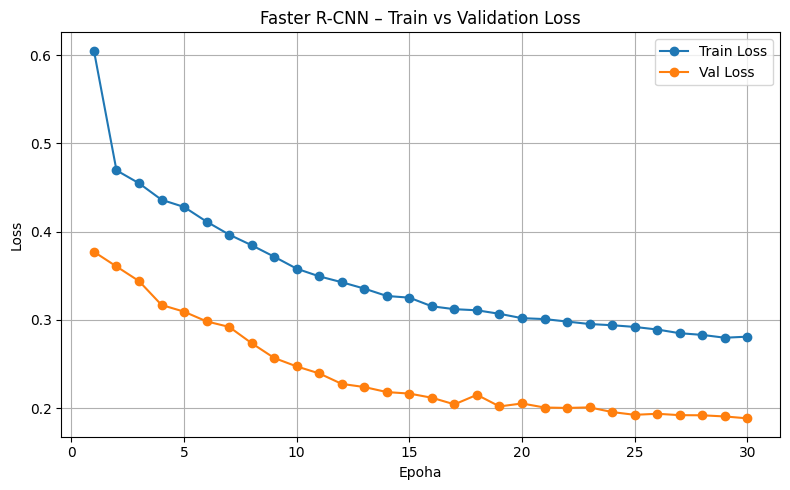

In [ ]:
# Treniranje

import torch
import torch.optim as optim
import copy
import matplotlib.pyplot as plt

# Optimizer
parameters = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.SGD(
    parameters,
    lr=1e-4,
    momentum=0.9,
    weight_decay=0.0005
)

# Parametri treniranja
num_epochs = 30
patience = 5

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")
counter = 0

train_losses = []
val_losses = []

# Treniranje modela
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for imgs, targets, _ in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_train_loss += losses.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validacija modela
    model.train()
    running_val_loss = 0.0

    with torch.no_grad():
        for imgs, targets, _ in val_loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            if all(len(t["boxes"]) == 0 for t in targets):
                continue

            loss_dict = model(imgs, targets)
            losses = sum(loss for loss in loss_dict.values())
            running_val_loss += losses.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # Early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping epoch: {epoch+1}")
            break

model.load_state_dict(best_model_wts)
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/VEDAI_slike/faster_rcnn_best.pth"
)

# Loss graf
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label="Train Loss", zorder=2)
plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label="Val Loss", zorder=2)
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Faster R-CNN – Train vs Validation Loss")
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(metrics_folder, "loss.png"))
plt.show()
plt.close()


In [ ]:
# Testiranje

import torch
import matplotlib.pyplot as plt
from torchvision.ops import box_iou, nms
import numpy as np
import os

model.eval()

IoU_threshold = 0.5
conf_threshold = 0.25
nms_threshold = 0.3

all_predictions = []
predictions = []
TP, FP, FN, ukupno = 0, 0, 0, 0

with torch.no_grad():
    for imgs, targets, names in test_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(imgs)

        for idx, (img, pred, gt) in enumerate(zip(imgs, outputs, targets)):

            gt_boxes = gt["boxes"]

            # Sve predikcije
            all_scores = pred["scores"]
            all_boxes = pred["boxes"]

            # Predikcije iznad conf
            keep = all_scores >= conf_threshold
            scores = all_scores[keep]
            pred_boxes = all_boxes[keep]

            if len(scores) > 0:
                sorted_idx = torch.argsort(scores, descending=True)
                scores = scores[sorted_idx]
                pred_boxes = pred_boxes[sorted_idx]

                # NMS
                keep_idx = nms(pred_boxes, scores, nms_threshold)
                scores = scores[keep_idx]
                pred_boxes = pred_boxes[keep_idx]

            ukupno += len(pred_boxes)

            # all_predictions
            all_predictions.append({
                "scores": all_scores.cpu(),
                "boxes": all_boxes.cpu(),
                "gt_boxes": gt_boxes.cpu(),
                "image": img.cpu(),
                "img_name": names[0]
            })

            # predictions
            predictions.append({
                "scores": scores.cpu(),
                "boxes": pred_boxes.cpu(),
                "gt_boxes": gt_boxes.cpu(),
                "image": img.cpu(),
                "img_name": names[0]
            })

            # Računanje TP, FP i FN
            if len(gt_boxes) == 0:
                FP += len(pred_boxes)
                continue
            if len(pred_boxes) == 0:
                FN += len(gt_boxes)
                continue

            ious = box_iou(pred_boxes, gt_boxes)
            matched_gt = set()

            for pred_idx in range(len(pred_boxes)):
                max_iou, gt_idx = ious[pred_idx].max(0)
                if max_iou >= IoU_threshold and gt_idx.item() not in matched_gt:
                    TP += 1
                    matched_gt.add(gt_idx.item())
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)

print("Ukupno predikcija:", ukupno)
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)

Ukupno predikcija: 633
TP: 223
FP: 410
FN: 32


In [ ]:
# Računanje metrika

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

# Računanje mAP50
all_APs = []

for pred in all_predictions:
    scores = pred["scores"]
    boxes = pred["boxes"]
    gt_boxes = pred["gt_boxes"]

    if len(gt_boxes) == 0 and len(boxes) == 0:
        all_APs.append(1.0)
        continue
    elif len(gt_boxes) == 0 or len(boxes) == 0:
        all_APs.append(0.0)
        continue

    sorted_idx = torch.argsort(scores, descending=True)
    scores = scores[sorted_idx]
    boxes = boxes[sorted_idx]

    ious = box_iou(boxes, gt_boxes)
    matched_gt = set()
    tp_list, fp_list = [], []

    for pred_idx in range(len(boxes)):
        max_iou, gt_idx = ious[pred_idx].max(0)
        if max_iou >= IoU_threshold and gt_idx.item() not in matched_gt:
            tp_list.append(1)
            fp_list.append(0)
            matched_gt.add(gt_idx.item())
        else:
            tp_list.append(0)
            fp_list.append(1)

    tp_cum = np.cumsum(tp_list)
    fp_cum = np.cumsum(fp_list)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

    all_APs.append(np.max(precisions))

mAP50 = np.mean(all_APs)

print("Izračunato")


Izračunato


Precision: 0.3523
Recall: 0.8745
F1 score: 0.5023
mAP50: 0.9278


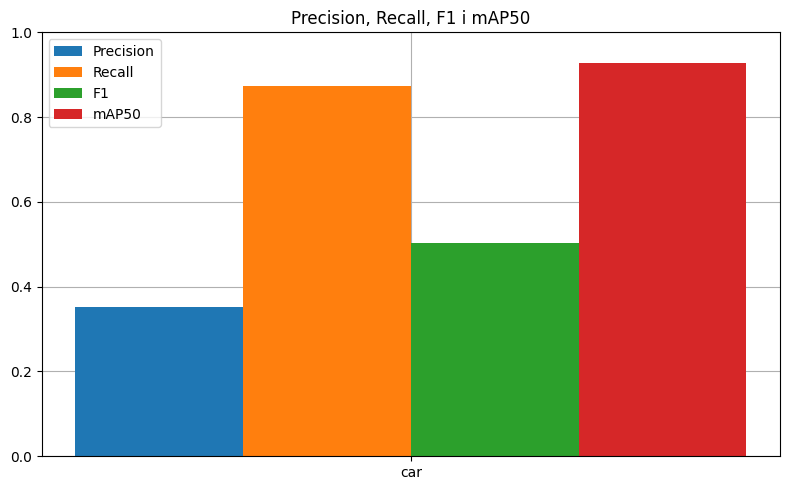

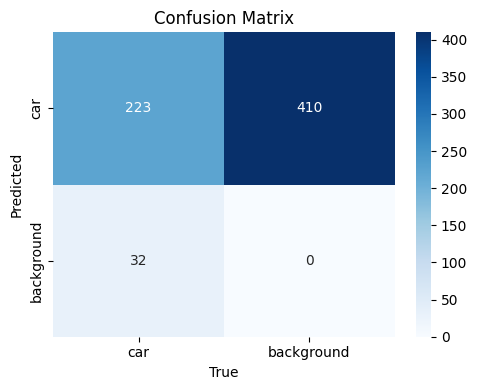

In [ ]:
# Ispis grafa metrika i konfuzijske matrice

import seaborn as sns

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"mAP50: {mAP50:.4f}")

# Ispis grafa metrika
klase = ["car"]

plt.figure(figsize=(8,5))
bar_width = 0.2
x = np.arange(len(klase))
plt.bar(x - bar_width*1.5, [precision], width=bar_width, label="Precision")
plt.bar(x - bar_width/2, [recall], width=bar_width, label="Recall")
plt.bar(x + bar_width/2, [f1], width=bar_width, label="F1")
plt.bar(x + bar_width*1.5, [mAP50], width=bar_width, label="mAP50")
plt.xticks(x, klase)
plt.ylim(0, 1)
plt.title("Precision, Recall, F1 i mAP50")
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(metrics_folder, "metrics.png"))
plt.show()
plt.close()

# Confusion matrix graf
conf_matrix = np.array([[TP, FP],
                        [FN, 0]])
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["car", "background"],
            yticklabels=["car", "background"])
plt.title("Confusion Matrix")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(metrics_folder, "confusion_matrix.png"))
print("\n\n")
plt.show()
plt.close()

In [ ]:
# Ispis i spremanje predikcija sa ground truth

from matplotlib.patches import FancyBboxPatch

for idx, pred in enumerate(predictions):

    img = pred["image"].permute(1,2,0).numpy()
    boxes = pred["boxes"].numpy()
    gt_boxes = pred["gt_boxes"].numpy()

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    img_disp = img * std + mean
    img_disp = np.clip(img_disp, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_disp)

    for box in boxes:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1

        plt.gca().add_patch(
            FancyBboxPatch(
                (x1, y1),
                width,
                height,
                boxstyle="Round,pad=0.0,rounding_size=3",
                fill=False,
                edgecolor="#1f2cc8",
                linewidth=1.8
            )
        )

    for gt in gt_boxes:
        gx1, gy1, gx2, gy2 = gt
        plt.gca().add_patch(
            plt.Rectangle(
                (gx1, gy1),
                gx2 - gx1,
                gy2 - gy1,
                fill=False,
                edgecolor="red",
                linewidth=1
            )
        )

    plt.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    plt.savefig(
        os.path.join(pred_folder, pred["img_name"]),
        bbox_inches='tight',
        pad_inches=0
    )
    plt.show()

Output hidden; open in https://colab.research.google.com to view.